# NBR and dNBR calculation and Severity Classification (USGS)
NIR/SWIR2 pre- and post-fire band processing for A Rua fire.

**Libraries**

In [2]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm

**Paths**

In [15]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUT_PREFIRE_DIR = os.path.join(OUTPUT_DIR, 'prefire')
OUT_POSTFIRE_DIR = os.path.join(OUTPUT_DIR, 'postfire')

PREFIRE_CLIP = os.path.join(OUT_PREFIRE_DIR, 'nir_swir2_clip_prefire.tif')
POSTFIRE_CLIP = os.path.join(OUT_POSTFIRE_DIR, 'nir_swir2_clip_postfire.tif')

PREFIRE_NBR = os.path.join(OUT_PREFIRE_DIR, 'prefire_nbr.tif')
POSTFIRE_NBR = os.path.join(OUT_POSTFIRE_DIR, 'postfire_nbr.tif')
DNBR_PATH = os.path.join(OUTPUT_DIR, 'dnbr.tif')
SEVERITY_PATH = os.path.join(OUTPUT_DIR, 'severity.tif')


**Functions**

In [13]:
def calculate_nbr_tile(tile_path, out_path):
    with rasterio.open(tile_path) as src:
        nir = src.read(1).astype("float32")
        swir2 = src.read(2).astype("float32")

        #Valid mask: both bands > 0
        valid_mask = (nir > 0) & (swir2 > 0)
        nbr = np.full(nir.shape, -9999, dtype = "float32")
        nbr[valid_mask] = (nir[valid_mask] - swir2[valid_mask]) / (nir[valid_mask] + swir2[valid_mask] + 1e-10)
    
        meta = src.meta.copy()
        meta.update({
            "count": 1,
            "dtype": "float32",
            "nodata": -9999
        })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(nbr, 1)

    return nbr

def calculate_dnbr_tile(prefire_nbr_path, postfire_nbr_path, out_path):
    with rasterio.open(prefire_nbr_path) as pre_src:
        pre_nbr = pre_src.read(1).astype("float32")
        meta = pre_src.meta.copy()

    with rasterio.open(postfire_nbr_path) as post_src:
        post_nbr = post_src.read(1).astype("float32")

    #Valid mask: both NBR != nodata
    valid_mask = (pre_nbr != meta["nodata"]) & (post_nbr != meta["nodata"])

    # dNBR = pre - post
    dnbr = np.full(pre_nbr.shape, -9999, dtype="float32")
    dnbr[valid_mask] = pre_nbr[valid_mask] - post_nbr[valid_mask]

    meta.update({
        "count": 1,
        "dtype": "float32",
        "nodata": -9999
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(dnbr, 1)

    return dnbr

def reclassify_dnbr(dnbr_path, out_path):
    with rasterio.open(dnbr_path) as src:
        dnbr = src.read(1).astype("float32")
        meta = src.meta.copy()
        nodata = src.nodata if src.nodata is not None else -9999

    severity = np.full(dnbr.shape, -1, dtype="int16")

    #Only reclassify where dnbr != nodata
    valid = (dnbr != nodata)

    # USGS thresholds
    severity[valid & (dnbr < 0.10)] = 0
    severity[valid & (dnbr >= 0.10) & (dnbr < 0.27)] = 1
    severity[valid & (dnbr >= 0.27) & (dnbr < 0.44)] = 2
    severity[valid & (dnbr >= 0.44) & (dnbr < 0.66)] = 3
    severity[valid & (dnbr >= 0.66)] = 4

    meta.update({
        "count": 1,
        "dtype": "int16",
        "nodata": -1
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(severity, 1)

    return severity

**Calculate**

In [16]:
prefire_nbr = calculate_nbr_tile(
    PREFIRE_CLIP,
    PREFIRE_NBR   
)

postfire_nbr = calculate_nbr_tile(
    POSTFIRE_CLIP,
    POSTFIRE_NBR
)

dnbr = calculate_dnbr_tile(
    PREFIRE_NBR,
    POSTFIRE_NBR,
    DNBR_PATH
)

severity = reclassify_dnbr(
    DNBR_PATH,
    SEVERITY_PATH
)

**Plot**

C:\Users\User\AppData\Local\Temp\ipykernel_38328\366530938.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_severity = cm.get_cmap('RdYlGn_r', 5)


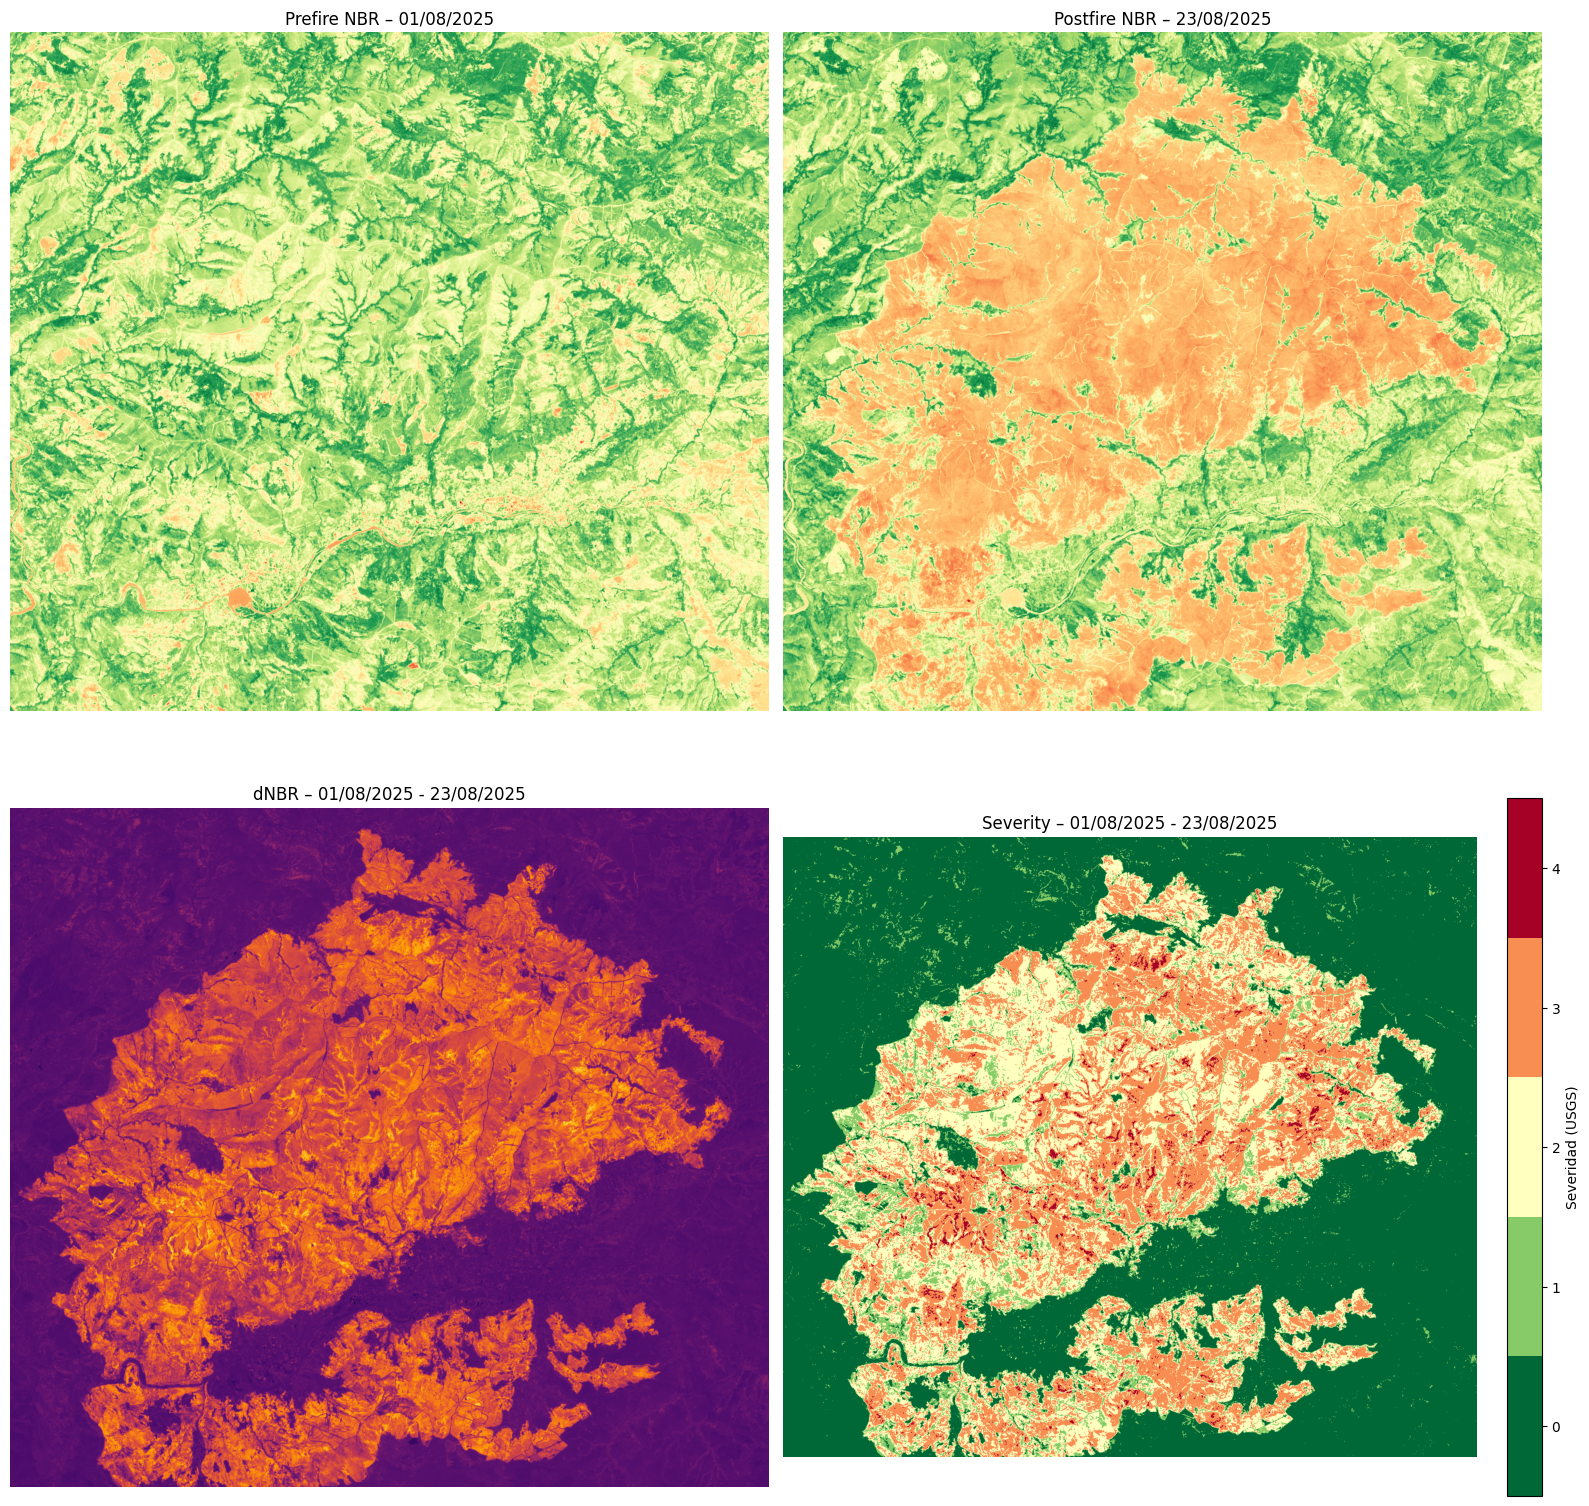

In [ ]:
# Colormap para severidad (0→blanco, 4→rojo oscuro)
cmap_severity = cm.get_cmap('RdYlGn_r', 5)

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Prefire NBR
im0 = axes[0, 0].imshow(prefire_nbr, cmap='RdYlGn')
axes[0, 0].set_title("Prefire NBR – 01/08/2025")
axes[0, 0].axis('off')

# Postfire NBR
im1 = axes[0, 1].imshow(postfire_nbr, cmap='RdYlGn')
axes[0, 1].set_title("Postfire NBR – 23/08/2025")
axes[0, 1].axis('off')

# dNBR
im2 = axes[1, 0].imshow(dnbr, cmap='inferno')
axes[1, 0].set_title("dNBR – 01/08/2025 - 23/08/2025")
axes[1, 0].axis('off')

# Severity (con colormap discreto)
im3 = axes[1, 1].imshow(
    severity,
    cmap=cmap_severity,
    vmin=-0.5,
    vmax=4.5
)
axes[1, 1].set_title("Severity – 01/08/2025 - 23/08/2025")
axes[1, 1].axis('off')

# Colorbar SOLO para severity
cbar = fig.colorbar(
    im3,
    ax=axes[1, 1],
    ticks=range(5),
    fraction=0.046,
    pad=0.04
)
cbar.set_label('Severidad (USGS)')

plt.tight_layout()
plt.show()